# Cafe Distances

This notebook:
1. Parses Google Maps links to extract cafe names and coordinates
2. Designates Peter Hall Unimelb as the depot where the coffee business will run from.
3. Computes a pairwise distance matrix (and travel-time matrix) using osrm, providing real road distances via the free OSRM public API.
4. Saves three clean CSVs: locations, distance matrix, time matrix
5. Displays an interactive distance heatmap

## Cafe Links

In [9]:
# Google maps links
LINKS = [
    ("Peter Hall Building UniMelb", "https://www.google.com/maps/place/Peter+Hall+Building/@-37.7982158,144.9636857,17z"),
    ("Proud Mary Coffee", "https://www.google.com/maps/place/Proud+Mary+Coffee/@-37.8023383,144.9851717,17z"),
    ("Patricia Coffee Brewers", "https://www.google.com/maps/place/Patricia+Coffee+Brewers/@-37.8146934,144.9582383,17z"),
    ("Seven Seeds Coffee Roasters", "https://www.google.com/maps/place/Seven+Seeds+Coffee+Roasters/@-37.8029711,144.9590027,17z"),
    ("Industry Beans Fitzroy", "https://www.google.com/maps/place/Industry+Beans+Fitzroy/@-37.7948113,144.9781341,17z"),
    ("Market Lane Coffee HQ", "https://www.google.com/maps/place/Market+Lane+Coffee+HQ/@-37.776348,144.972123,17z"),
    ("ST. ALi Coffee Roasters", "https://www.google.com/maps/place/ST+ALi+Coffee+Roasters/@-37.8312475,144.960354,17z"),
    ("Code Black Coffee Brunswick", "https://www.google.com/maps/place/Code+Black+Coffee+Brunswick/@-37.774643,144.962468,17z"),
    ("Axil Coffee Roasters", "https://www.google.com/maps/place/Axil+Coffee+Roasters/@-37.8226075,145.0342781,17z"),
    ("Dukes Coffee Roasters", "https://www.google.com/maps/place/Dukes+Coffee+Roasters/@-37.816791,144.966162,17z"),
    ("Rumble Coffee Roasters", "https://www.google.com/maps/place/Rumble+Coffee+Roasters/@-37.7947678,144.9342535,17z"),
    ("Wide Open Road", "https://www.google.com/maps/place/Wide+Open+Road/@-37.7763047,144.9612147,17z"),
    ("Aunty Peg's", "https://www.google.com/maps/place/Aunty+Pegs/@-37.8028093,144.9870052,17z"),
    ("Brother Baba Budan", "https://www.google.com/maps/place/Brother+Baba+Budan/@-37.813541,144.9620988,17z"),
    ("Lune Croissanterie Fitzroy", "https://www.google.com/maps/place/Lune+Croissanterie+Fitzroy/@-37.7959659,144.9799313,17z"),
    ("Small Batch Roasting Co.", "https://www.google.com/maps/place/Small+Batch+Roasting+Co/@-37.8043369,144.9545001,17z"),
    ("Padre Coffee Brunswick East", "https://www.google.com/maps/place/Padre+Coffee+Brunswick+East/@-37.7641144,144.9732824,17z"),
    ("Jasper Coffee Fitzroy", "https://www.google.com/maps/place/Jasper+Coffee+Fitzroy/@-37.799384,144.9781281,17z"),
    ("Everyday Coffee", "https://www.google.com/maps/place/Everyday+Coffee/@-37.7981641,144.9858767,17z"),
    ("MAKER Coffee South Yarra", "https://www.google.com/maps/place/MAKER+Coffee+South+Yarra/@-37.8394531,144.9963319,17z"),
    ("Square Lane Coffee", "https://www.google.com/maps/place/Square+Lane+Coffee/@-37.8269479,144.9929394,17z"),
    ("Disciple Roasters", "https://www.google.com/maps/place/Disciple+Roasters/@-37.775525,144.9601403,17z"),
    ("Coffee Supreme", "https://www.google.com/maps/place/Coffee+Supreme/@-37.8091416,145.006767,17z"),
    ("Market Lane Prahran Market", "https://www.google.com/maps/place/Market+Lane+Prahran+Market/@-37.845757,144.993288,17z"),
    ("Veneziano Coffee Richmond", "https://www.google.com/maps/place/Veneziano+Coffee+Richmond/@-37.8169555,145.0131324,17z"),
    ("Five Senses Coffee", "https://www.google.com/maps/place/Five+Senses+Coffee/@-37.8108846,144.9455841,17z"),
    ("Standing Room Fitzroy North", "https://www.google.com/maps/place/Standing+Room+Fitzroy+North/@-37.7847929,144.9823376,17z"),
    ("Bench Coffee Co. Roastery", "https://www.google.com/maps/place/Bench+Coffee+Co+Roastery/@-37.761889,144.961811,17z"),
    ("Path Melbourne", "https://www.google.com/maps/place/Path+Melbourne/@-37.8054501,144.9542036,17z"),
    ("Little Rogue", "https://www.google.com/maps/place/Little+Rogue/@-37.810993,144.964066,17z"),
    ("Vacation Coffee CBD", "https://www.google.com/maps/place/Vacation+Coffee+CBD/@-37.8158579,144.9720281,17z"),
    ("Market Lane Carlton", "https://www.google.com/maps/place/Market+Lane+Carlton/@-37.8014,144.9672,17z"),
    ("Traveller Coffee", "https://www.google.com/maps/place/Traveller+Coffee/@-37.8109,144.9668,17z"),
    ("Core Roasters", "https://www.google.com/maps/place/Core+Roasters/@-37.7775,144.9722,17z"),
    ("Project Zero", "https://www.google.com/maps/place/Project+Zero/@-37.8175,144.964,17z"),
]

# Depot is at Peter Hall!!!
DEPOT_INDEX = 0
METHOD = "osrm"
OUTPUT_DIR = "../data/real"
PLOT_DIR = "../plots"

## Parse Google Maps Links and Get Coordinates

In [10]:
import re
import csv
import math
import time
import json
import urllib.request
import urllib.parse
import os
from typing import Optional

os.makedirs(OUTPUT_DIR, exist_ok=True)


In [11]:
COORD_PATTERNS = [
    re.compile(r'/@(-?\d+\.\d+),(-?\d+\.\d+)'),
    re.compile(r'[?&]q=(-?\d+\.\d+),(-?\d+\.\d+)'),
    re.compile(r'[?&]query=(-?\d+\.\d+),(-?\d+\.\d+)'),
    re.compile(r'[?&]ll=(-?\d+\.\d+),(-?\d+\.\d+)'),
    re.compile(r'!3d(-?\d+\.\d+)!4d(-?\d+\.\d+)'),
]
NAME_PATTERN = re.compile(r'/maps/place/([^/@]+)')


def _http_get(url: str, timeout: int = 15):
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    return urllib.request.urlopen(req, timeout=timeout)


def resolve_short_url(url: str) -> str:
    """Follow redirects on goo.gl / maps.app.goo.gl short links."""
    try:
        with _http_get(url) as resp:
            return resp.url
    except Exception as e:
        print(f"  Warning: could not resolve {url!r}: {e}")
        return url


def extract_name_from_url(url: str) -> Optional[str]:
    m = NAME_PATTERN.search(url)
    return urllib.parse.unquote_plus(m.group(1)).replace("+", " ") if m else None


def extract_coords(url: str) -> Optional[tuple]:
    working = url.strip()
    parsed = urllib.parse.urlparse(working)
    if parsed.netloc in ("goo.gl", "maps.app.goo.gl"):
        print("  Resolving short URL...")
        working = resolve_short_url(working)
        print(f"  → {working[:100]}")
    for pat in COORD_PATTERNS:
        m = pat.search(working)
        if m:
            return float(m.group(1)), float(m.group(2))
    return None


def parse_links(raw: list) -> list:
    locations = []
    for i, item in enumerate(raw):
        name_hint, url = item if isinstance(item, tuple) else ("", item)
        print(f"[{i+1}/{len(raw)}] {url[:80]}{'…' if len(url) > 80 else ''}")
        coords = extract_coords(url)
        if coords is None:
            print("  ✗ coordinates not found — skipped")
            continue
        lat, lng = coords
        name = name_hint or extract_name_from_url(url) or f"Location {i+1}"
        print(f"{name}  lat={lat}  lng={lng}")
        locations.append({"name": name, "url": url, "lat": lat, "lng": lng})
    return locations


print("Parsing links...\n")
locations = parse_links(LINKS)
print(f"\n{len(locations)} locations parsed.")
print(f"Depot: [{DEPOT_INDEX}] {locations[DEPOT_INDEX]['name']}")


Parsing links...

[1/35] https://www.google.com/maps/place/Peter+Hall+Building/@-37.7982158,144.9636857,1…
Peter Hall Building UniMelb  lat=-37.7982158  lng=144.9636857
[2/35] https://www.google.com/maps/place/Proud+Mary+Coffee/@-37.8023383,144.9851717,17z
Proud Mary Coffee  lat=-37.8023383  lng=144.9851717
[3/35] https://www.google.com/maps/place/Patricia+Coffee+Brewers/@-37.8146934,144.95823…
Patricia Coffee Brewers  lat=-37.8146934  lng=144.9582383
[4/35] https://www.google.com/maps/place/Seven+Seeds+Coffee+Roasters/@-37.8029711,144.9…
Seven Seeds Coffee Roasters  lat=-37.8029711  lng=144.9590027
[5/35] https://www.google.com/maps/place/Industry+Beans+Fitzroy/@-37.7948113,144.978134…
Industry Beans Fitzroy  lat=-37.7948113  lng=144.9781341
[6/35] https://www.google.com/maps/place/Market+Lane+Coffee+HQ/@-37.776348,144.972123,1…
Market Lane Coffee HQ  lat=-37.776348  lng=144.972123
[7/35] https://www.google.com/maps/place/ST+ALi+Coffee+Roasters/@-37.8312475,144.960354…
ST. ALi Coffee 

## Calculate Distance Matrix

Calculates using OSRM (road distances)

In [12]:
OSRM_BASE = "http://router.project-osrm.org/table/v1/driving"

def build_osrm_matrix(locs):
    coords_str = ";".join(f"{loc['lng']},{loc['lat']}" for loc in locs)
    url = f"{OSRM_BASE}/{coords_str}?annotations=distance,duration"
    print("Calling OSRM table API...")
    with _http_get(url) as resp:
        data = json.loads(resp.read())
    if data.get("code") != "Ok":
        raise RuntimeError(f"OSRM error: {data.get('message', data)}")
    n = len(locs)
    dist  = [[data["distances"][i][j] / 1000.0 for j in range(n)] for i in range(n)]
    time_ = [[data["durations"][i][j] / 60.0   for j in range(n)] for i in range(n)]
    return dist, time_

print("OSRM helper defined.")

OSRM helper defined.


In [13]:
dist_matrix, time_matrix = build_osrm_matrix(locations)
print("OSRM matrix built (road km + driving minutes).")

Calling OSRM table API...
OSRM matrix built (road km + driving minutes).


In [14]:
def write_locations_csv(locs, depot_idx, path):
    with open(path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["name", "latitude", "longitude", "is_depot"])
        for i, loc in enumerate(locs):
            w.writerow([loc["name"], loc["lat"], loc["lng"],
                        "yes" if i == depot_idx else "no"])


def write_matrix_csv(matrix, labels, path):
    with open(path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow([""] + labels)
        for label, row in zip(labels, matrix):
            w.writerow([label] + [
                "" if math.isnan(v) else f"{v:.4f}" for v in row
            ])


labels = [loc["name"] for loc in locations]

loc_path  = os.path.join(OUTPUT_DIR, "locations.csv")
dist_path = os.path.join(OUTPUT_DIR, "distance_matrix.csv")
time_path = os.path.join(OUTPUT_DIR, "time_matrix.csv")

write_locations_csv(locations, DEPOT_INDEX, loc_path)
print(f"Saved: {loc_path}")

write_matrix_csv(dist_matrix, labels, dist_path)
print(f"Saved: {dist_path}")

write_matrix_csv(time_matrix, labels, time_path)
print(f"Saved: {time_path}")
print("\nAll CSVs written.")


Saved: ../data/real\locations.csv
Saved: ../data/real\distance_matrix.csv
Saved: ../data/real\time_matrix.csv

All CSVs written.


## Preview Results

In [15]:
# Quick table preview
def print_table(matrix, labels, title, unit):
    col_w = max(len(l) for l in labels) + 2
    header = f"{'':>{col_w}}" + "".join(f"{l:>{col_w}}" for l in labels)
    print(f"\n{title} ({unit})")
    print("─" * len(header))
    print(header)
    for label, row in zip(labels, matrix):
        vals = "".join(
            f"{'—':>{col_w}}" if math.isnan(v) else f"{v:>{col_w}.2f}"
            for v in row
        )
        print(f"{label:>{col_w}}{vals}")

print_table(dist_matrix, labels, "Distance Matrix", "km")
if time_matrix:
    print_table(time_matrix, labels, "Travel Time Matrix", "min")



Distance Matrix (km)
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────

## Distance Heatmap

Visualises the distance matrix.

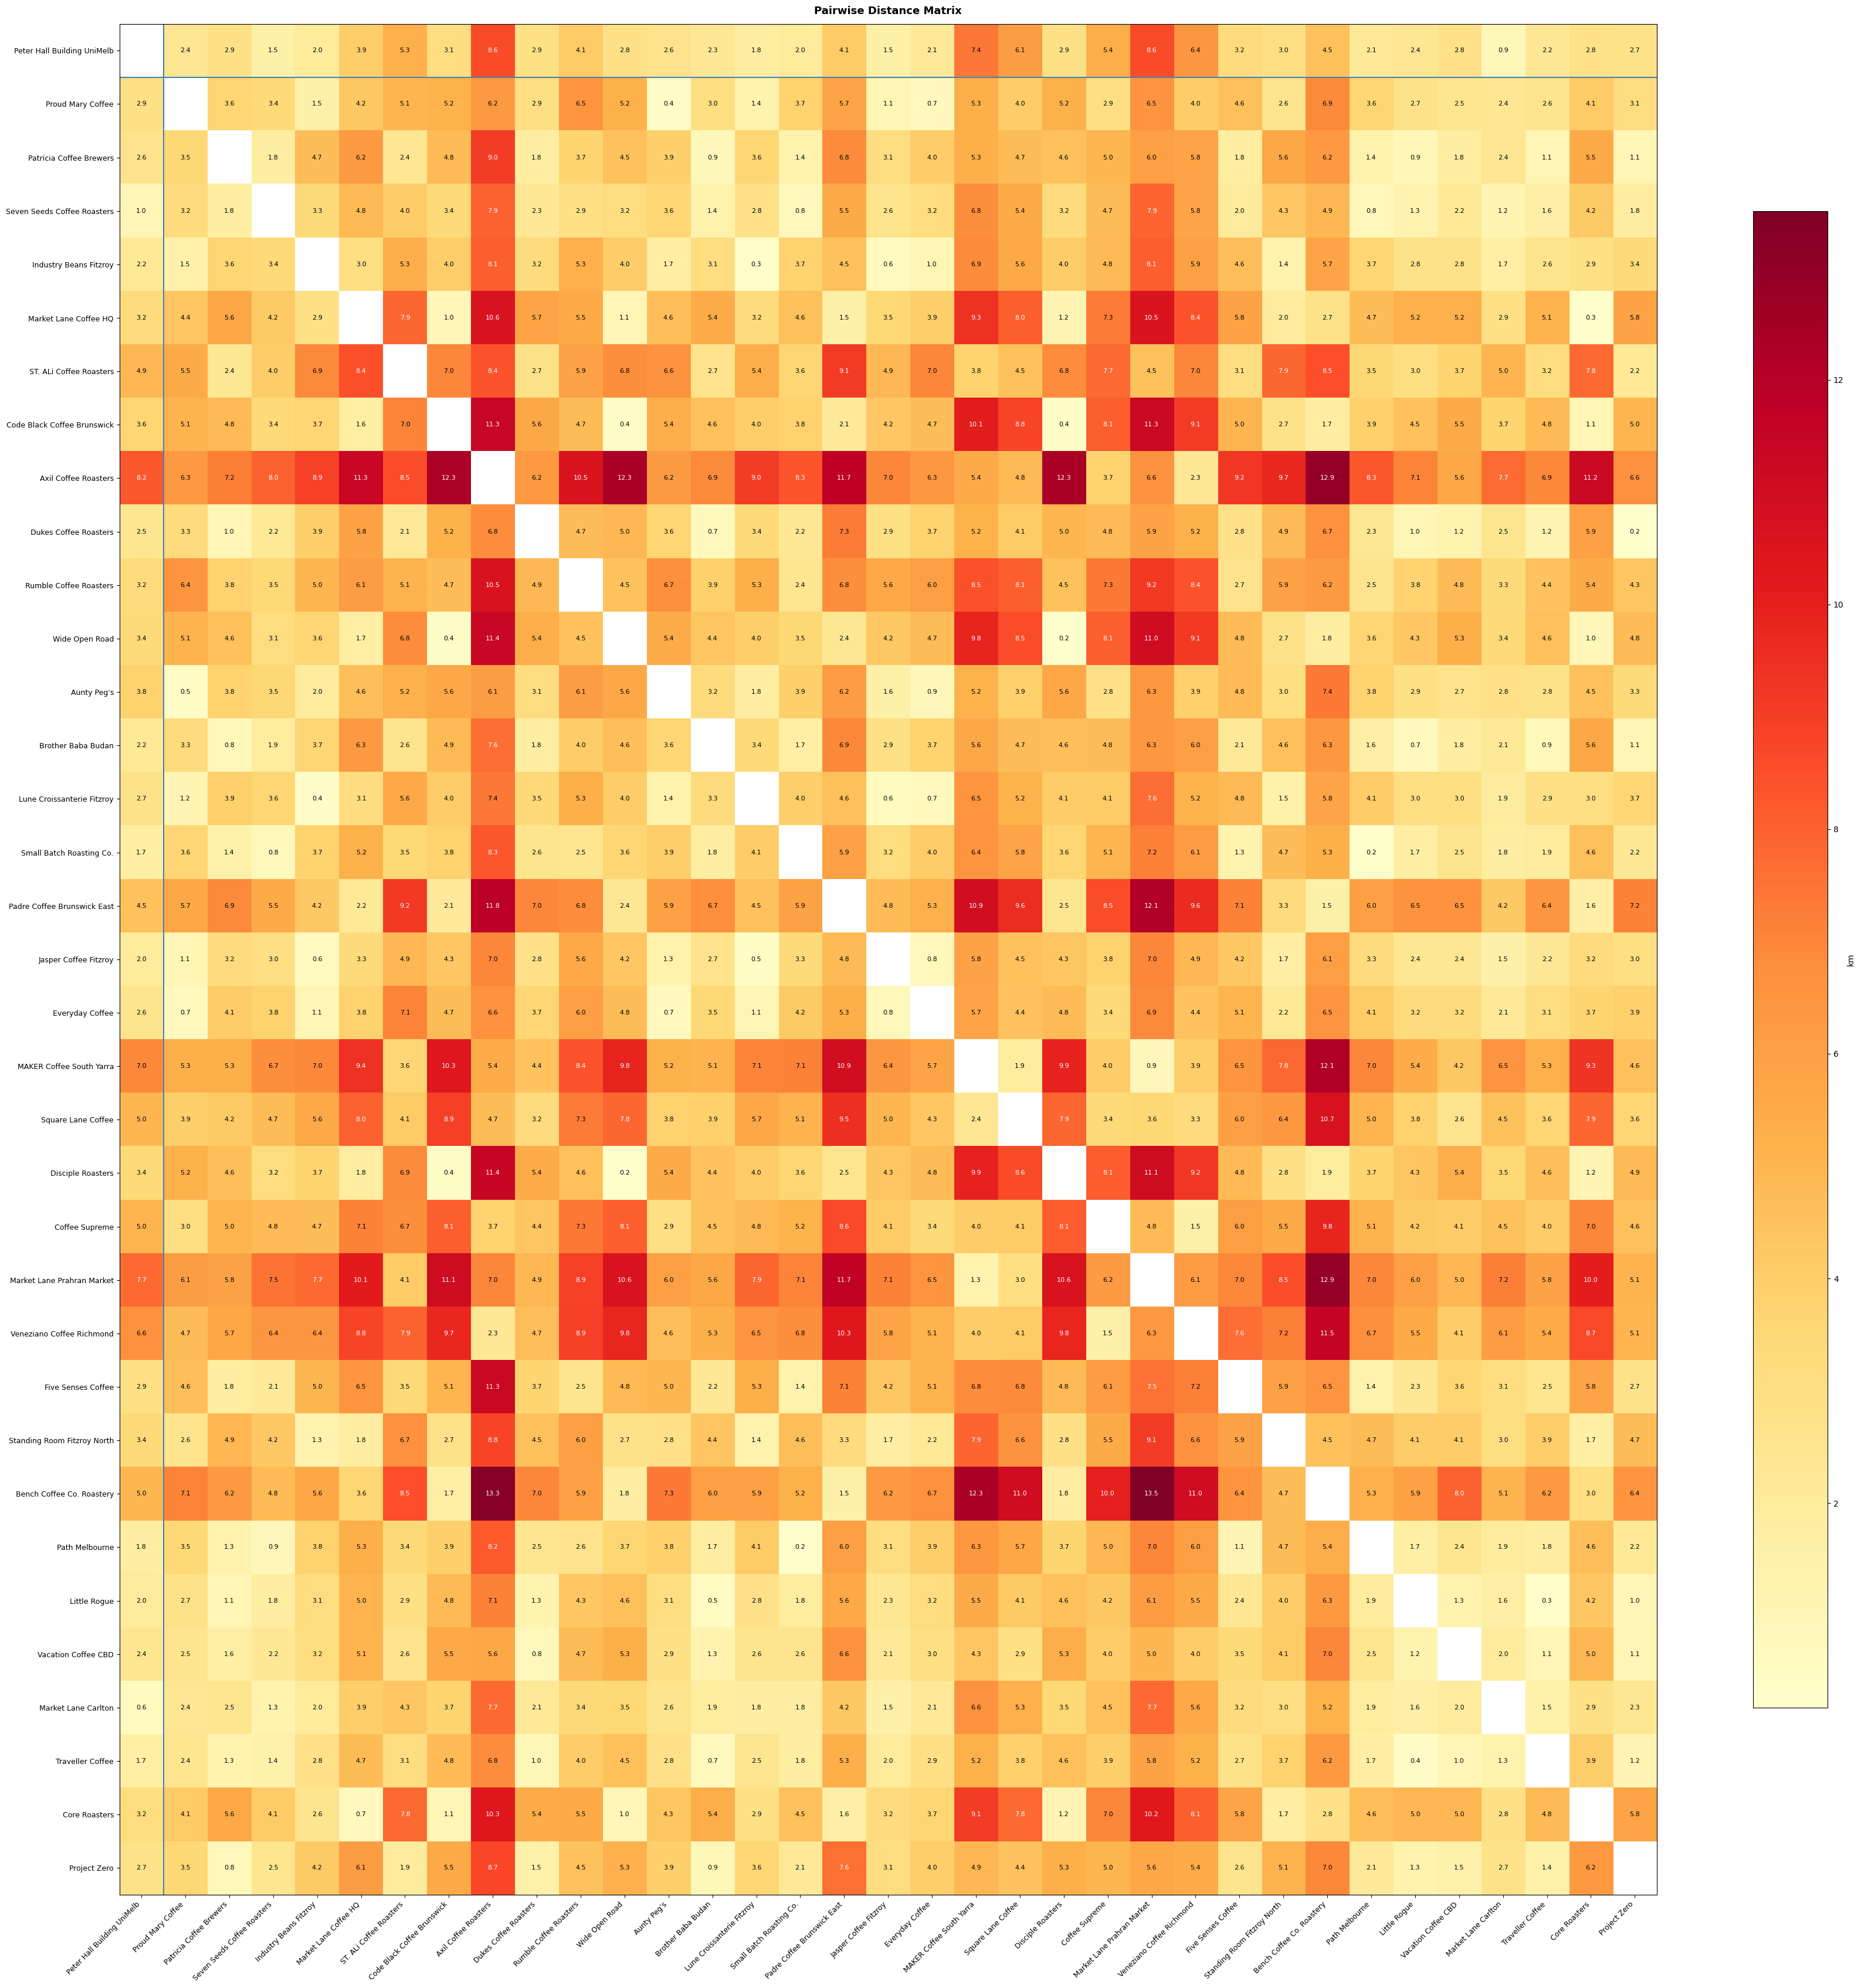

Heatmap saved to output/distance_heatmap.png


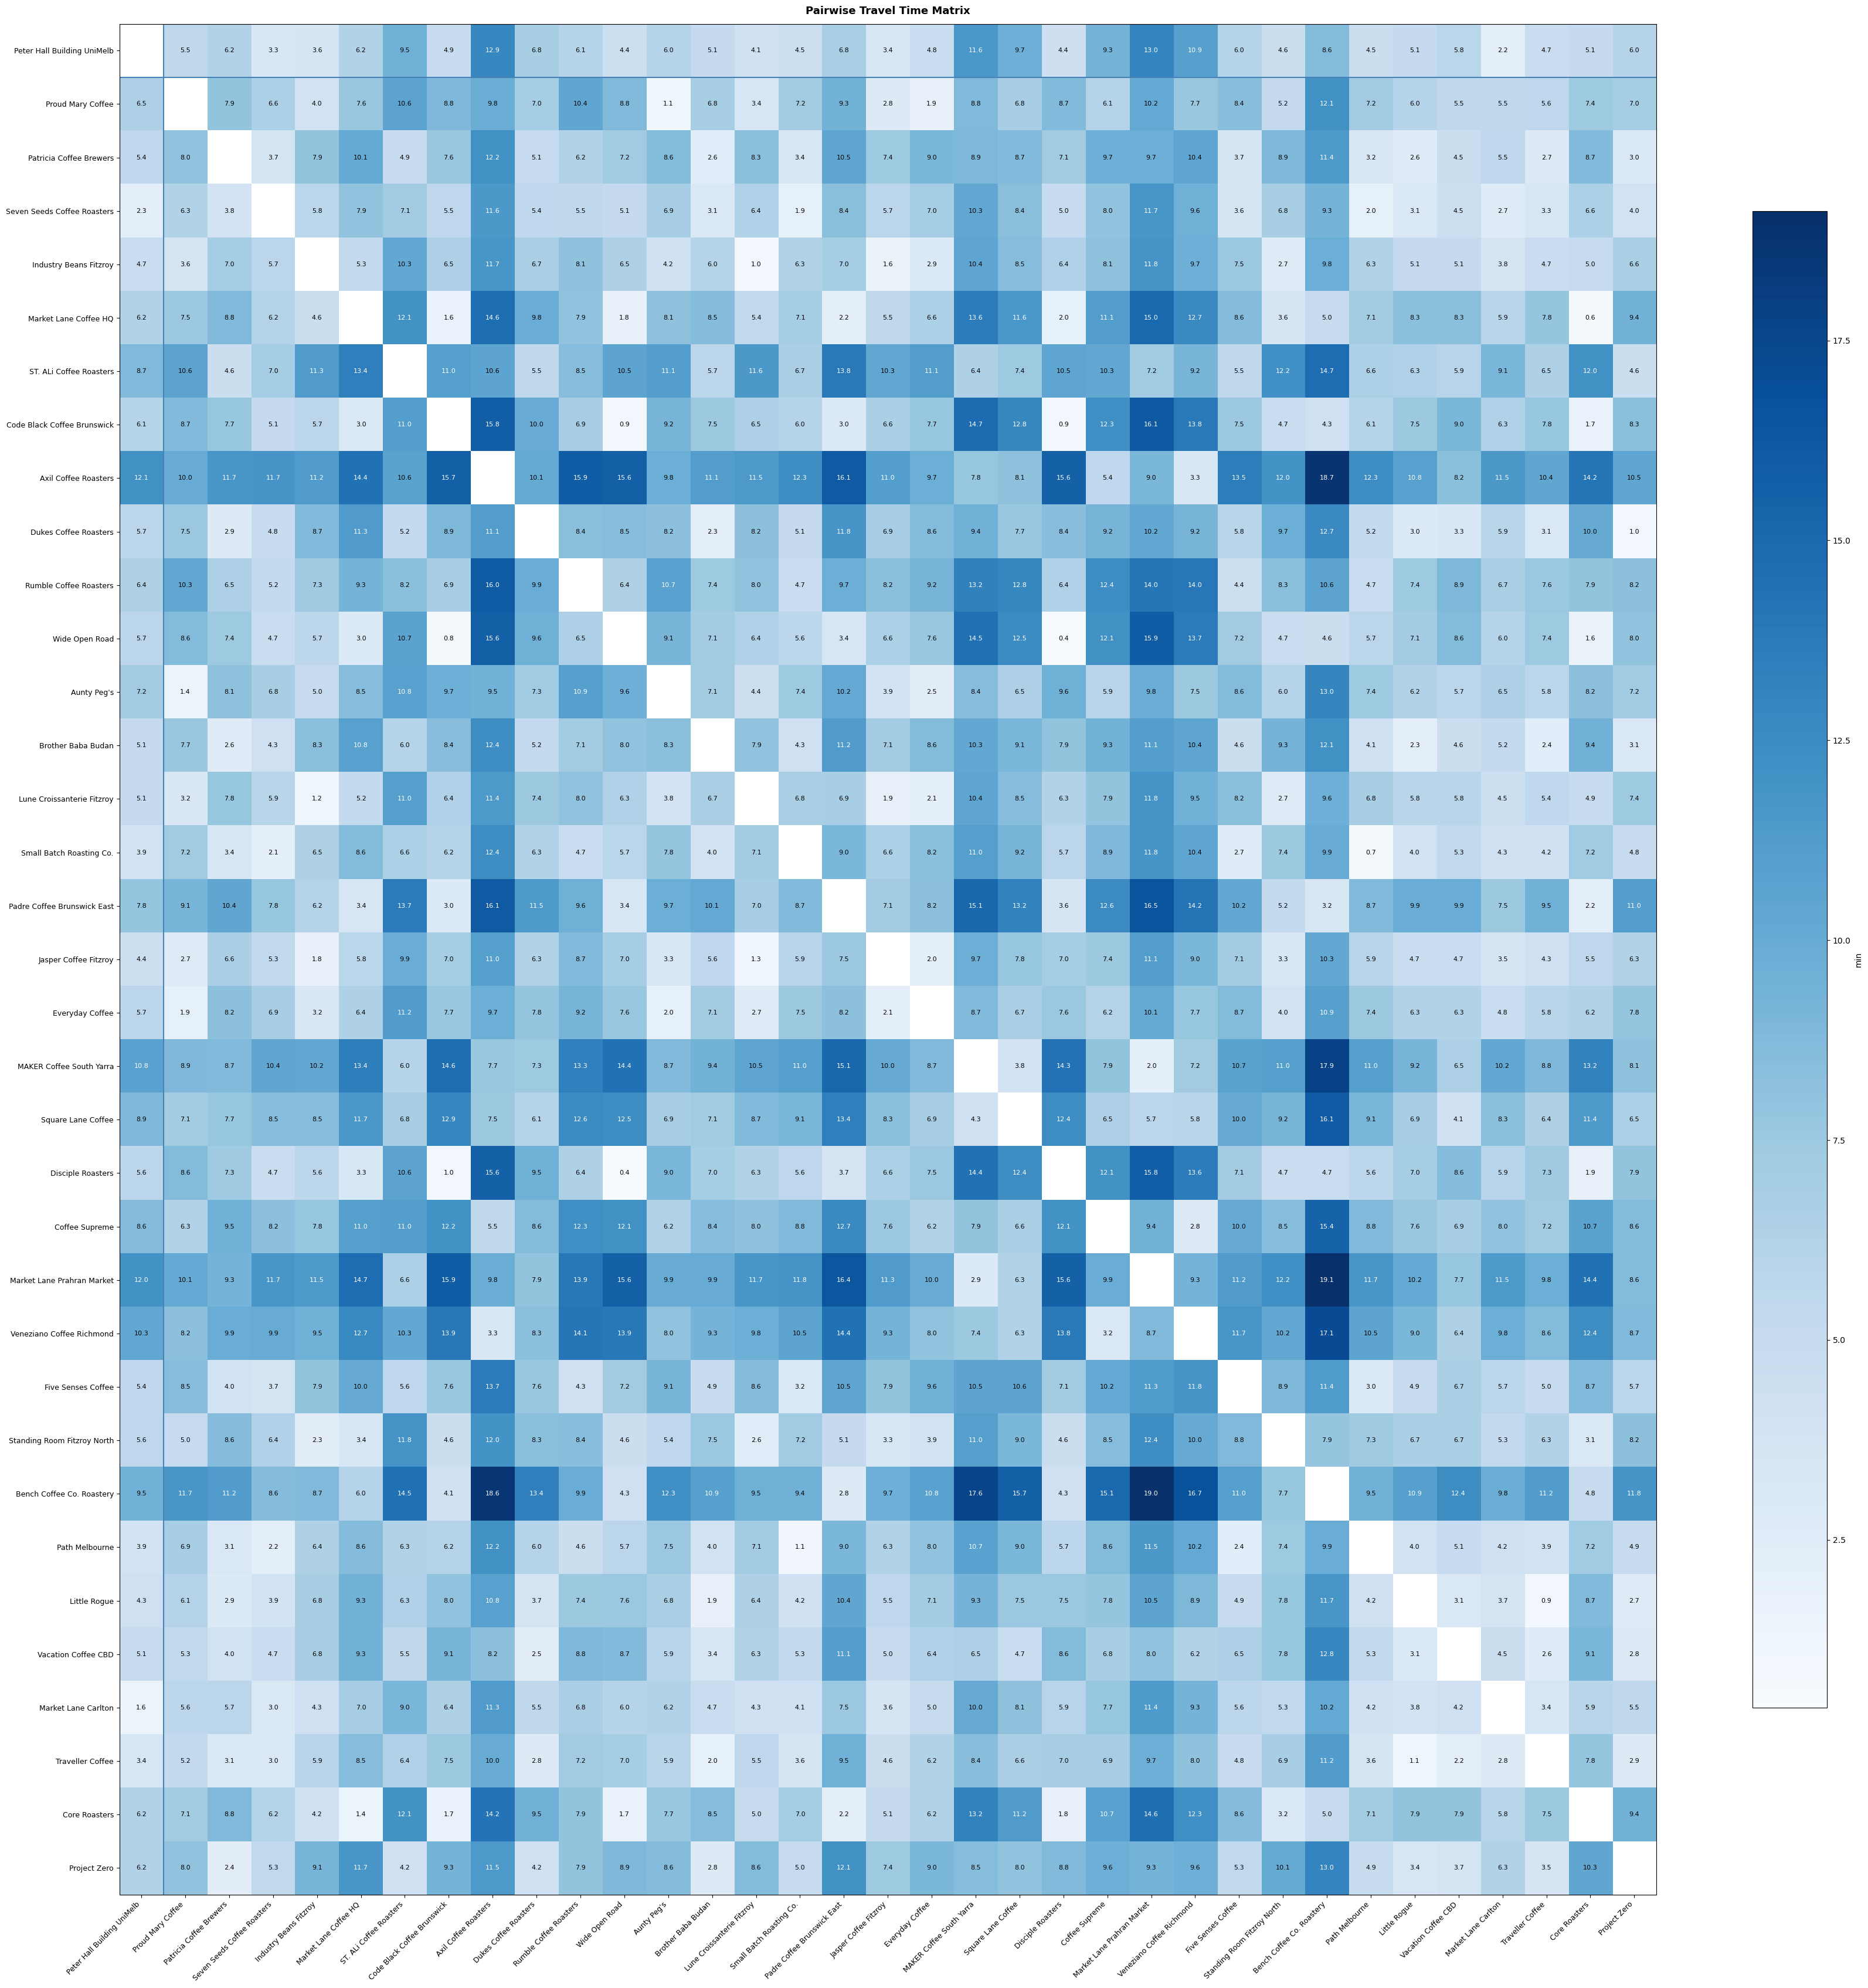

Time heatmap saved to output/time_heatmap.png


In [16]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def plot_heatmap(matrix, labels, title, unit, cmap="YlOrRd"):
    n = len(labels)
    fig, ax = plt.subplots(figsize=(max(6, n), max(5, n - 1)))
    # Mask diagonal (self-distance = 0)
    import copy
    display = copy.deepcopy(matrix)
    for i in range(n):
        display[i][i] = float("nan")
    flat = [v for row in display for v in row if not math.isnan(v)]
    vmin, vmax = min(flat), max(flat)
    im = ax.imshow(display, cmap=cmap, vmin=vmin, vmax=vmax, aspect="auto")
    ax.set_xticks(range(n)); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=9)
    ax.set_yticks(range(n)); ax.set_yticklabels(labels, fontsize=9)
    for i in range(n):
        for j in range(n):
            v = display[i][j]
            if not math.isnan(v):
                norm = (v - vmin) / (vmax - vmin + 1e-9)
                color = "white" if norm > 0.55 else "black"
                ax.text(j, i, f"{v:.1f}", ha="center", va="center",
                        fontsize=8, color=color)
    plt.colorbar(im, ax=ax, label=unit, shrink=0.8)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=12)
    # Highlight depot row/col
    ax.axhline(DEPOT_INDEX - 0.5, color="steelblue", lw=1.5)
    ax.axhline(DEPOT_INDEX + 0.5, color="steelblue", lw=1.5)
    ax.axvline(DEPOT_INDEX - 0.5, color="steelblue", lw=1.5)
    ax.axvline(DEPOT_INDEX + 0.5, color="steelblue", lw=1.5)
    plt.tight_layout()
    return fig

fig = plot_heatmap(dist_matrix, labels, "Pairwise Distance Matrix", "km")
fig.savefig(os.path.join(PLOT_DIR, "distance_heatmap.png"), dpi=150)
plt.show()
print("Heatmap saved to output/distance_heatmap.png")

if time_matrix:
    fig2 = plot_heatmap(time_matrix, labels, "Pairwise Travel Time Matrix", "min", cmap="Blues")
    fig2.savefig(os.path.join(PLOT_DIR, "time_heatmap.png"), dpi=150)
    plt.show()
    print("Time heatmap saved to output/time_heatmap.png")


## Summary

All outputs are saved in the current directory:

| File | Description |
|---|---|
| `data/real/locations.csv` | Name, lat, lng, depot flag |
| `data/real/distance_matrix.csv` | N×N road distances in km |
| `data/real/time_matrix.csv` | N×N travel times in minutes |
| `plots/distance_heatmap.png` | Visual heatmap of distances |
| `plots/time_heatmap.png` | Visual heatmap of travel times |
